# Exploring OlmoEarth activations

Everything produced by the pipeline, in one place:

| Stage | Script | Output |
|---|---|---|
| Encode | `encode_location.py` | `<name>.npz`, `<name>_chip.npz` |
| Label | `fetch_labels.py` | `<name>_labels.npz` |
| Correlate | `correlate_labels.py` | `label_correlations.csv` |

Nothing here runs the model or downloads anything. It reads what is already on
disk, so every cell is cheap and re-runnable.

**Set `LOCATION` and `LABEL` in the parameters cell** and re-run from there down.

## Setup

In [14]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo() -> Path:
    """Walk up for the repository root, so the notebook works from anywhere."""
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("not inside the repository")


REPO = find_repo()
PKG = REPO / "code" / "activations"
ARTIFACTS = PKG / "artifacts"
CORRELATIONS = ARTIFACTS / "label_correlations.csv"

# Import the package itself, for the location registry and label metadata.
sys.path.insert(0, str(PKG))
from olmoearth_activations import locations as loc  # noqa: E402

print(f"repo      {REPO}")
print(f"artifacts {ARTIFACTS}")
print(f"locations {', '.join(loc.load_locations())}")

repo      /Users/carl/Desktop/Work Projects/embeddings-health
artifacts /Users/carl/Desktop/Work Projects/embeddings-health/code/activations/artifacts
locations dc, dc_medical, rock_creek, silver_spring, gaithersburg, westminster, carroll_farmland, poolesville


## Loaders

One function per artifact type. `RGB` uses bands 2/1/0 — the band order is
`B02 B03 B04 B08 ...`, so red/green/blue are indices 2, 1, 0 — with a percentile
stretch, because a few bright roofs otherwise crush everything else to grey.

In [ ]:
def load_embeddings(name: str) -> np.ndarray:
    """Return (H, W, D) embeddings for a location."""
    with np.load(ARTIFACTS / name / f"{name}.npz", allow_pickle=True) as data:
        return data["embeddings"]


def load_chip(name: str) -> np.ndarray:
    """Return the raw (H, W, 12) reflectance chip."""
    with np.load(ARTIFACTS / name / f"{name}_chip.npz") as data:
        return data["chip"]


def load_labels(name: str) -> dict[str, np.ndarray]:
    """Return {label: (H', W') coverage fraction} for a location."""
    path = ARTIFACTS / name / f"{name}_labels.npz"
    if not path.exists():
        return {}
    with np.load(path, allow_pickle=True) as data:
        names = [str(v) for v in data["label_names"]]
        grids = data["labels"]
        sources = (
            [str(v) for v in data["label_sources"]]
            if "label_sources" in data
            else ["osm"] * len(names)
        )
    LABEL_SOURCE.update(dict(zip(names, sources)))
    return {n: grids[i] for i, n in enumerate(names)}


LABEL_SOURCE: dict[str, str] = {}


def display_label(label: str) -> str:
    """Annotate a label with its source, matching fetch_labels.py."""
    tag = {"worldcover": "WorldCover", "osm": "OSM"}.get(
        LABEL_SOURCE.get(label, "osm"), "?"
    )
    shown = label[4:] if label.startswith("osm_") else label
    return f"{tag}-{shown}"


def rgb(chip: np.ndarray, low: float = 2.0, high: float = 98.0) -> np.ndarray:
    """Percentile-stretched true-colour composite."""
    out = chip[:, :, [2, 1, 0]].astype(np.float32)
    lo, hi = np.percentile(out, low), np.percentile(out, high)
    return np.clip((out - lo) / max(hi - lo, 1e-6), 0, 1)


def available() -> pd.DataFrame:
    """What exists on disk, per location."""
    rows = []
    for name in loc.load_locations():
        emb = ARTIFACTS / name / f"{name}.npz"
        labels = load_labels(name)
        rows.append(
            {
                "location": name,
                "embeddings": emb.exists(),
                "chip": (ARTIFACTS / name / f"{name}_chip.npz").exists(),
                "n_labels": len(labels),
                "labels": ", ".join(sorted(labels)) or "-",
            }
        )
    return pd.DataFrame(rows)


available()

,location,embeddings,chip,n_labels,labels
0,dc,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
1,dc_medical,True,True,13,"agriculture, buildings, built, canopy, farmlan..."
2,rock_creek,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
3,silver_spring,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
4,gaithersburg,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
5,westminster,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
6,carroll_farmland,True,True,14,"agriculture, buildings, built, canopy, farmlan..."
7,poolesville,False,False,0,-


## Parameters

**This is the cell to edit.** Everything below reads from it.

In [38]:
LOCATION = "silver_spring"   # any location with artifacts -- see the table above
LABEL = "healthcare"           # any label present for that location
TOP_K = 6                  # how many dimensions to show

emb = load_embeddings(LOCATION)
chip = load_chip(LOCATION)
labels = load_labels(LOCATION)

print(f"{LOCATION}: embeddings {emb.shape}, chip {chip.shape}")
print(f"labels available: {', '.join(display_label(k) for k in sorted(labels))}")
if LABEL not in labels:
    print(f"\n!! {LABEL!r} not among them -- pick one of the above")

silver_spring: embeddings (64, 64, 128), chip (256, 256, 12)
labels available: WorldCover-agriculture, OSM-buildings, WorldCover-built, WorldCover-canopy, WorldCover-farmland, OSM-food_retail, WorldCover-grass, OSM-healthcare, OSM-park, OSM-parking, OSM-recreation, OSM-roads, OSM-walkability, WorldCover-water


## 1. Most spatially variable dimensions

Ranked by standard deviation across patches. Worth remembering this is a
*selection effect*: sorting 128 dimensions by variance surfaces the loudest, not
the most structured, so a noisy-looking panel here is expected rather than
alarming.

,dim,std,range,mean
0,97,0.245835,1.399446,-0.687244
1,19,0.234109,1.525117,-0.100314
2,44,0.226592,1.361974,-0.141403
3,63,0.216293,1.199839,0.221063
4,76,0.210572,1.176981,-0.107445
5,106,0.209487,1.616371,-0.120008


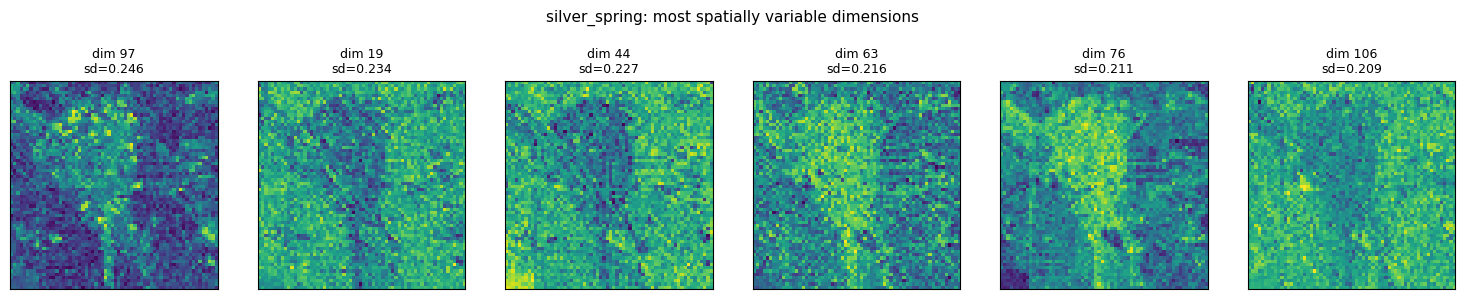

In [39]:
def most_variable(emb: np.ndarray, k: int) -> pd.DataFrame:
    """Rank dimensions by spatial standard deviation."""
    flat = emb.reshape(-1, emb.shape[-1])
    frame = pd.DataFrame(
        {
            "dim": np.arange(flat.shape[1]),
            "std": flat.std(axis=0),
            "range": flat.max(axis=0) - flat.min(axis=0),
            "mean": flat.mean(axis=0),
        }
    )
    return frame.sort_values("std", ascending=False).head(k).reset_index(drop=True)


ranked = most_variable(emb, TOP_K)
display(ranked)

fig, axes = plt.subplots(1, TOP_K, figsize=(2.5 * TOP_K, 3.0), squeeze=False)
for ax, row in zip(axes[0], ranked.itertuples(index=False)):
    ax.imshow(emb[:, :, int(row.dim)], cmap="viridis", interpolation="nearest")
    ax.set_title(f"dim {int(row.dim)}\nsd={row.std:.3f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"{LOCATION}: most spatially variable dimensions", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 2. The most variable dimension, beside the imagery

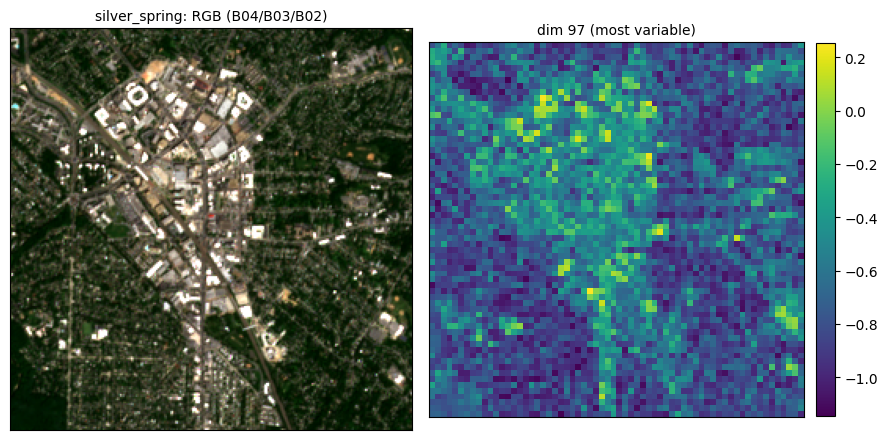

In [40]:
best = int(ranked.iloc[0]["dim"])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
axes[0].imshow(rgb(chip))
axes[0].set_title(f"{LOCATION}: RGB (B04/B03/B02)", fontsize=10)
im = axes[1].imshow(emb[:, :, best], cmap="viridis", interpolation="nearest")
axes[1].set_title(f"dim {best} (most variable)", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.03)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## 3. The scene, labelled

Every label for this location. These layers **overlap and do not partition** the
chip — a patch can be both canopy and park — and the WorldCover ones cover every
pixel while the OSM ones do not.

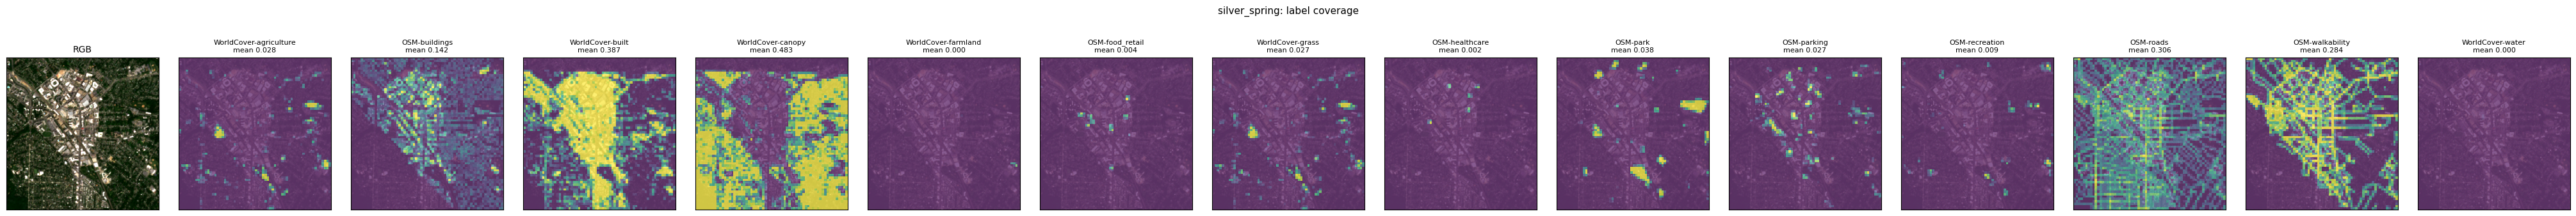

In [41]:
def show_labels(name: str, labels: dict[str, np.ndarray], chip: np.ndarray) -> None:
    """RGB plus every label mask, overlaid on the imagery."""
    order = sorted(labels)
    cols = len(order) + 1
    fig, axes = plt.subplots(1, cols, figsize=(2.7 * cols, 3.4), squeeze=False)
    axes[0][0].imshow(rgb(chip))
    axes[0][0].set_title("RGB", fontsize=10)
    axes[0][0].set_xticks([]); axes[0][0].set_yticks([])
    for ax, label in zip(axes[0][1:], order):
        ax.imshow(rgb(chip), alpha=0.5)
        ax.imshow(
            labels[label], cmap="viridis", alpha=0.65, vmin=0, vmax=1,
            interpolation="nearest",
            extent=(0, chip.shape[1], chip.shape[0], 0),
        )
        ax.set_title(
            f"{display_label(label)}\nmean {float(labels[label].mean()):.3f}",
            fontsize=8,
        )
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{name}: label coverage", fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.88))
    plt.show()


show_labels(LOCATION, labels, chip)

## 4. Run the correlation

Shells out to `correlate_labels.py` so the notebook and the command line cannot
drift apart. Set `RERUN = False` to just load the existing CSV.

The number to trust is **`probe_r2_oof`** — a linear probe fit on every location
but one, predicting the held-out one, with all those predictions pooled into a
single R². In-sample R² over ~28,000 spatially autocorrelated patches would be
close to meaningless, since neighbouring patches share ground.

`worst_fold` is the least favourable individual fold. A very negative value there
alongside a reasonable pooled score means the label is concentrated in one
location, not that the model is anti-predicting it.

In [42]:
RERUN = True

if RERUN:
    result = subprocess.run(
        [
            sys.executable, "scripts/correlate_labels.py",
            "--all", "--top", "8", "--out", str(CORRELATIONS),
        ],
        cwd=PKG, capture_output=True, text=True,
    )
    print(result.stdout[-4000:])
    if result.returncode != 0:
        print("STDERR:\n", result.stderr[-2000:])

corr = pd.read_csv(CORRELATIONS)
print(f"\n{len(corr)} rows, labels: {', '.join(sorted(corr['label'].unique()))}")
corr.head(12)

age 0.005
grass        coverage 0.1421  7 location(s)  best dim   3 r=-0.390  probe R2 (pooled out-of-fold) +0.499
             top dims: 3:-0.390  92:-0.349  15:+0.327  113:+0.314  58:-0.309  114:-0.309  65:-0.307  21:-0.297
             per held-out location: carroll_farmland=+0.40, dc=-0.12, dc_medical=+0.54, gaithersburg=+0.49, rock_creek=-1.15, silver_spring=-0.17, westminster=+0.52
             note: worst fold R2 -1.15. A fold that extreme means the held-out location has almost no variance in this label -- read the pooled figure, not the folds.

healthcare   coverage 0.0119  7 location(s)  best dim  26 r=-0.136  probe R2 (pooled out-of-fold) -0.144
             top dims: 26:-0.136  59:+0.117  61:+0.116  92:+0.112  29:-0.112  102:-0.103  76:+0.101  57:-0.100
             per held-out location: carroll_farmland=+nan, dc=-0.78, dc_medical=-0.05, gaithersburg=-1.63, rock_creek=-1.88, silver_spring=-0.55, westminster=-1.43
             note: worst fold R2 -1.88. A fold that extreme m

,label,dim,pearson_r,abs_r,label_mean_coverage,probe_r2_oof,probe_r2_fold_min,probe_r2_fold_max,n_patches,n_locations
0,agriculture,3,-0.392854,0.392854,0.157179,0.541977,-1.421268,0.596847,28672,7
1,agriculture,92,-0.392064,0.392064,0.157179,0.541977,-1.421268,0.596847,28672,7
2,agriculture,65,-0.355453,0.355453,0.157179,0.541977,-1.421268,0.596847,28672,7
3,agriculture,113,0.351256,0.351256,0.157179,0.541977,-1.421268,0.596847,28672,7
4,agriculture,15,0.335415,0.335415,0.157179,0.541977,-1.421268,0.596847,28672,7
5,agriculture,114,-0.331187,0.331187,0.157179,0.541977,-1.421268,0.596847,28672,7
6,agriculture,58,-0.326750,0.326750,0.157179,0.541977,-1.421268,0.596847,28672,7
7,agriculture,85,-0.323419,0.323419,0.157179,0.541977,-1.421268,0.596847,28672,7
8,buildings,53,0.493903,0.493903,0.136150,0.469096,-19.024454,0.435645,28672,7
9,buildings,26,-0.477763,0.477763,0.136150,0.469096,-19.024454,0.435645,28672,7


### Which labels are linearly decodable at all?

One row per label. A strong `probe_r2_oof` alongside a weak `best_r` means the
concept is real but **spread across dimensions** — no single coordinate carries
it. That is the situation sparse autoencoders exist to address.

Read `n_locations` and `coverage` alongside the score. Below roughly 0.03
coverage there are too few positive patches to probe at all, whatever the model
encodes — which is a limit of this sample, not of the model.

,best_dim,best_r,probe_r2_oof,worst_fold,coverage,n_locations,n_patches
label,,,,,,,
built,26,-0.768,+0.846,-0.23,0.4208,7,"28,672"
canopy,26,+0.609,+0.690,+0.48,0.4009,7,"28,672"
agriculture,3,-0.393,+0.542,-1.42,0.1572,7,"28,672"
grass,3,-0.390,+0.499,-1.15,0.1421,7,"28,672"
buildings,53,+0.494,+0.469,-19.02,0.1361,7,"28,672"
roads,3,+0.493,+0.463,-0.52,0.2806,7,"28,672"
walkability,3,+0.424,+0.268,-0.19,0.2928,7,"28,672"
farmland,89,+0.331,+0.242,-61.56,0.0151,7,"28,672"
parking,26,-0.197,+0.059,-0.42,0.0290,7,"28,672"


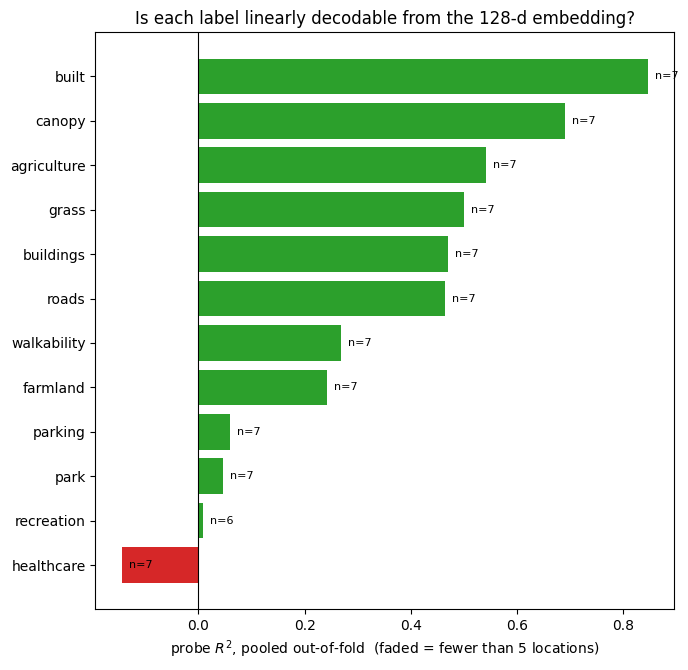

In [43]:
summary = (
    corr.groupby("label")
    .agg(
        best_dim=("abs_r", lambda s: int(corr.loc[s.idxmax(), "dim"])),
        best_r=("pearson_r", lambda s: s.loc[s.abs().idxmax()]),
        probe_r2_oof=("probe_r2_oof", "first"),
        worst_fold=("probe_r2_fold_min", "first"),
        coverage=("label_mean_coverage", "first"),
        n_locations=("n_locations", "first"),
        n_patches=("n_patches", "first"),
    )
    .sort_values("probe_r2_oof", ascending=False)
)
display(summary.style.format({
    "best_r": "{:+.3f}", "probe_r2_oof": "{:+.3f}", "worst_fold": "{:+.2f}",
    "coverage": "{:.4f}", "n_patches": "{:,.0f}",
}))

fig, ax = plt.subplots(figsize=(7, 0.45 * len(summary) + 1.4))
# n_locations is part of the reading, not a footnote: a label measured on two
# locations is train-on-one test-on-one and is not comparable to one measured
# across seven. Faded bars mark those.
colours = [
    ("tab:green" if v > 0 else "tab:red")
    for v in summary["probe_r2_oof"]
]
alphas = [1.0 if n >= 5 else 0.45 for n in summary["n_locations"]]
bars = ax.barh(summary.index, summary["probe_r2_oof"], color=colours)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)
for y, (v, n) in enumerate(zip(summary["probe_r2_oof"], summary["n_locations"])):
    ax.text(v, y, f"  n={n}", va="center", fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("probe $R^2$, pooled out-of-fold  (faded = fewer than 5 locations)")
ax.set_title("Is each label linearly decodable from the 128-d embedding?")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

### Coverage is the limiting factor, not the label

Plotted because it was the clearest pattern in the first run: probe scores track
how much of the chip a label covers. Anything left of the dashed line has too few
positive patches for seven locations to support a probe, whatever the model
encodes.

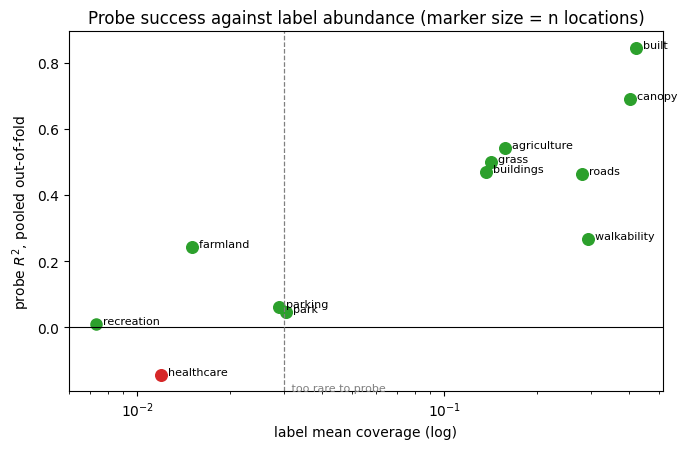

In [44]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for label, row in summary.iterrows():
    ax.scatter(row["coverage"], row["probe_r2_oof"],
               s=28 + 6 * row["n_locations"],
               color="tab:green" if row["probe_r2_oof"] > 0 else "tab:red")
    ax.annotate(f"  {label}", (row["coverage"], row["probe_r2_oof"]), fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0.03, color="grey", linestyle="--", linewidth=0.9)
ax.text(0.031, ax.get_ylim()[0], " too rare to probe", fontsize=8, color="grey")
ax.set_xscale("log")
ax.set_xlabel("label mean coverage (log)")
ax.set_ylabel("probe $R^2$, pooled out-of-fold")
ax.set_title("Probe success against label abundance (marker size = n locations)")
fig.tight_layout()
plt.show()

## 5. Top dimensions for a label, beside that label's mask

**The main cell.** Reads `label_correlations.csv`, pulls the highest-|r|
dimensions for `LABEL`, and puts each one next to the actual label mask for
`LOCATION`.

Change `LABEL` / `LOCATION` in the parameters cell and re-run. The correlations
are pooled across *all* locations, while the maps are for the one you chose — so
a dimension can rank highly overall and look unconvincing on a single chip.

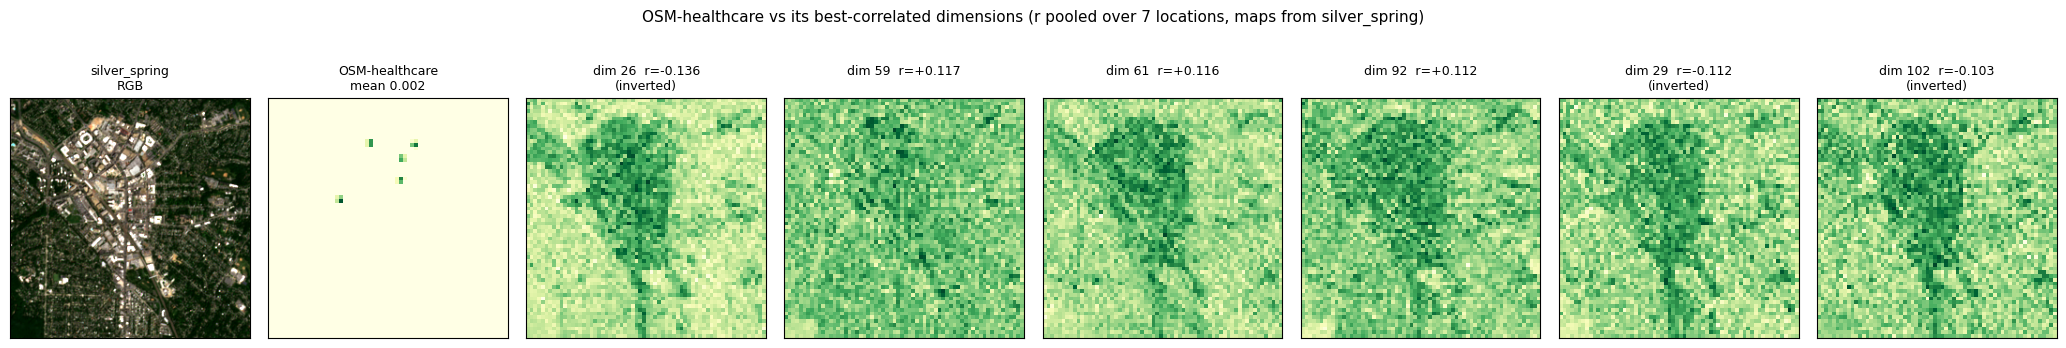

,dim,pearson_r,probe_r2_oof,n_patches,n_locations
48,26,-0.135564,-0.144316,28672,7
49,59,0.117499,-0.144316,28672,7
50,61,0.116244,-0.144316,28672,7
51,92,0.112347,-0.144316,28672,7
52,29,-0.111874,-0.144316,28672,7
53,102,-0.103097,-0.144316,28672,7


In [45]:
def compare_label_to_dims(
    location: str, label: str, top_k: int = 6, corr: pd.DataFrame | None = None
) -> pd.DataFrame:
    """Show a label mask beside the dimensions that correlate best with it."""
    table = pd.read_csv(CORRELATIONS) if corr is None else corr
    rows = table[table["label"] == label].copy()
    if rows.empty:
        raise ValueError(
            f"{label!r} not in {CORRELATIONS.name}. Available: "
            f"{', '.join(sorted(table['label'].unique()))}"
        )
    rows["abs_r"] = rows["pearson_r"].abs()
    rows = rows.sort_values("abs_r", ascending=False).head(top_k)

    emb = load_embeddings(location)
    chip = load_chip(location)
    labels = load_labels(location)
    if label not in labels:
        raise ValueError(
            f"{location!r} has no {label!r} label. It has: "
            f"{', '.join(sorted(labels))}"
        )
    mask = labels[label]

    n = len(rows)
    fig, axes = plt.subplots(1, n + 2, figsize=(2.6 * (n + 2), 3.5), squeeze=False)

    axes[0][0].imshow(rgb(chip))
    axes[0][0].set_title(f"{location}\nRGB", fontsize=9)

    axes[0][1].imshow(mask, cmap="YlGn", vmin=0, vmax=1, interpolation="nearest")
    axes[0][1].set_title(
        f"{display_label(label)}\nmean {float(mask.mean()):.3f}", fontsize=9
    )

    for ax, row in zip(axes[0][2:], rows.itertuples(index=False)):
        # Flip negatively-correlated dimensions so bright always means "more of
        # this label". Without it a strong negative relationship reads as an
        # unrelated pattern to the eye.
        values = emb[:, :, int(row.dim)]
        shown = -values if row.pearson_r < 0 else values
        ax.imshow(shown, cmap="YlGn", interpolation="nearest")
        sign = "(inverted)" if row.pearson_r < 0 else ""
        ax.set_title(
            f"dim {int(row.dim)}  r={row.pearson_r:+.3f}\n{sign}", fontsize=9
        )

    for ax in axes[0]:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(
        f"{display_label(label)} vs its best-correlated dimensions "
        f"(r pooled over {int(rows.iloc[0]['n_locations'])} locations, "
        f"maps from {location})",
        fontsize=11,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.86))
    plt.show()
    return rows[["dim", "pearson_r", "probe_r2_oof", "n_patches", "n_locations"]]


compare_label_to_dims(LOCATION, LABEL, TOP_K, corr)

### Sweep every label for this location

The same comparison for each label at once — useful for spotting which concepts
the model separates cleanly and which it does not.

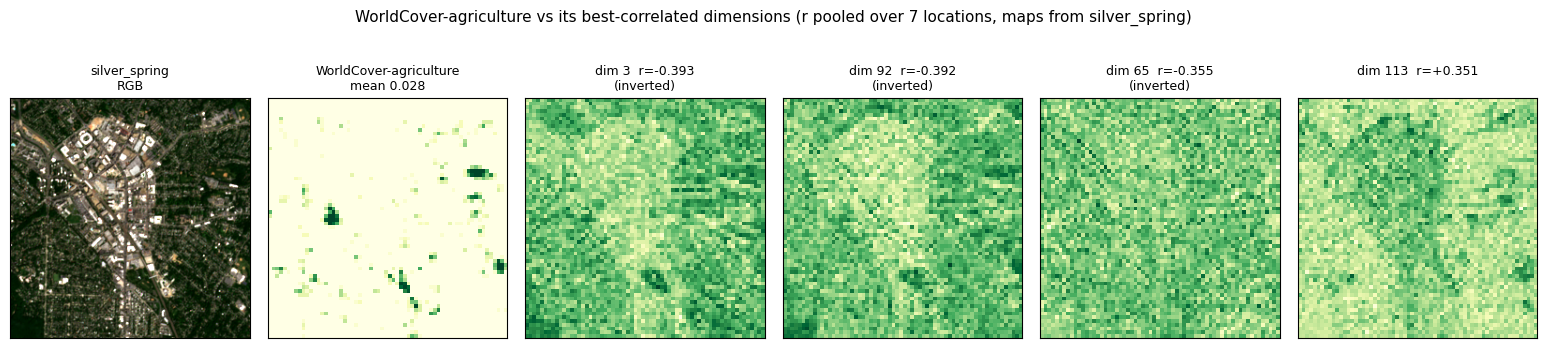

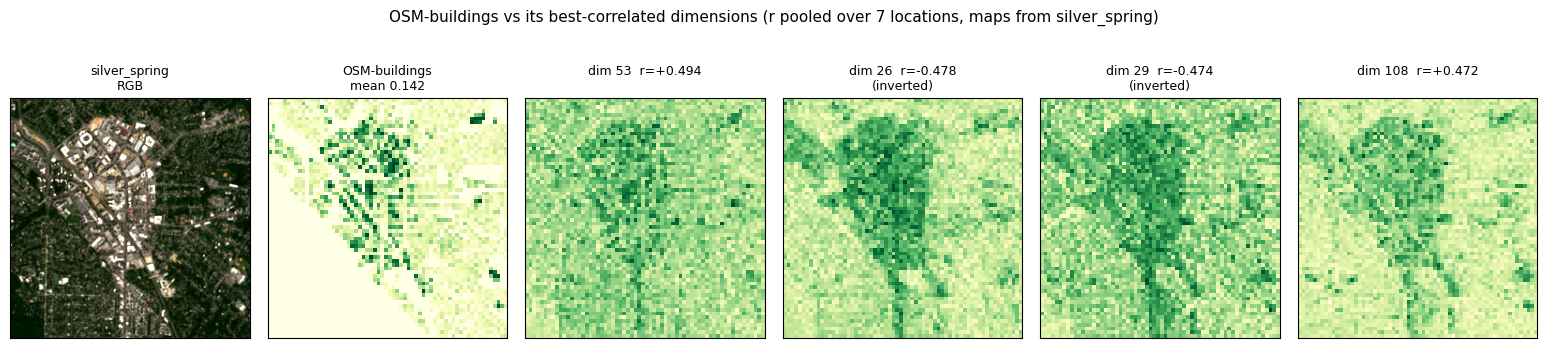

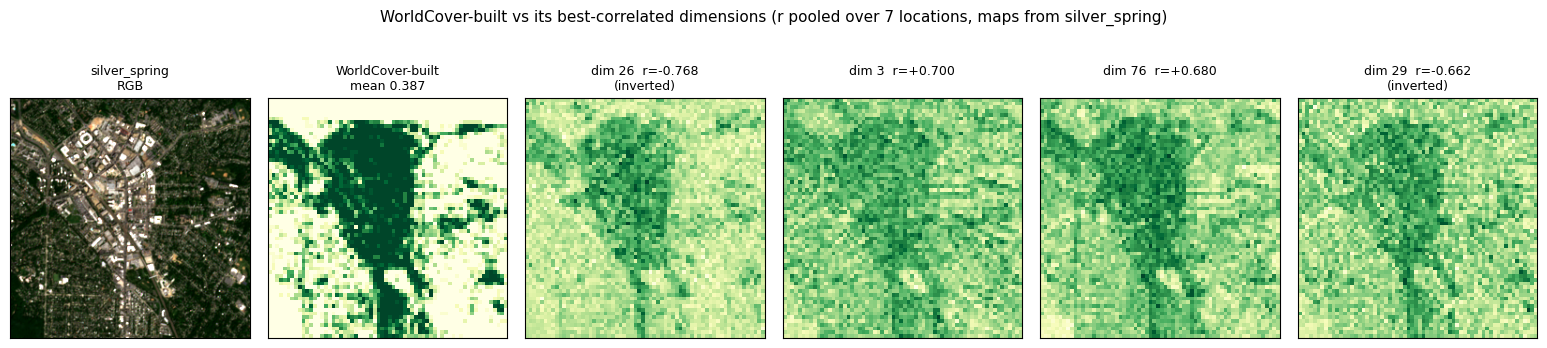

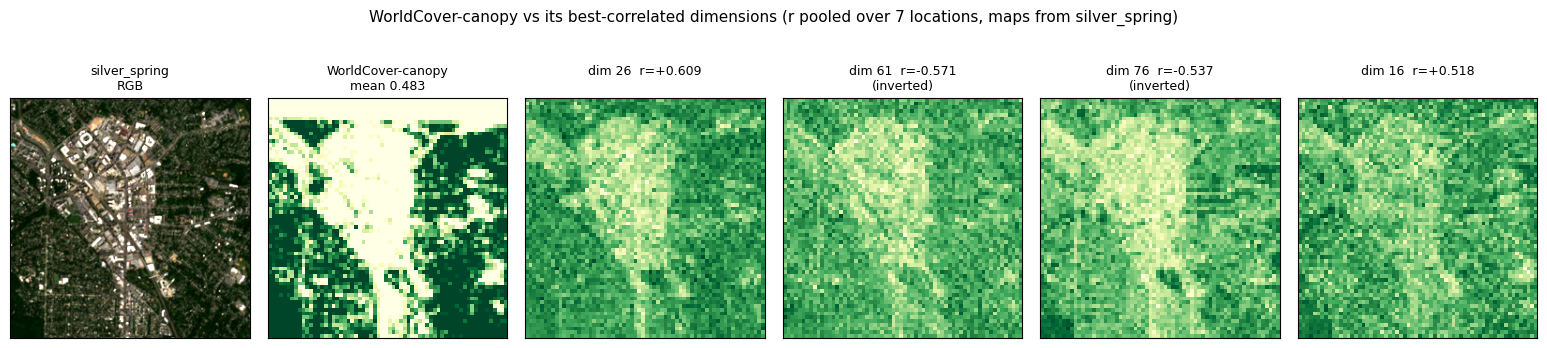

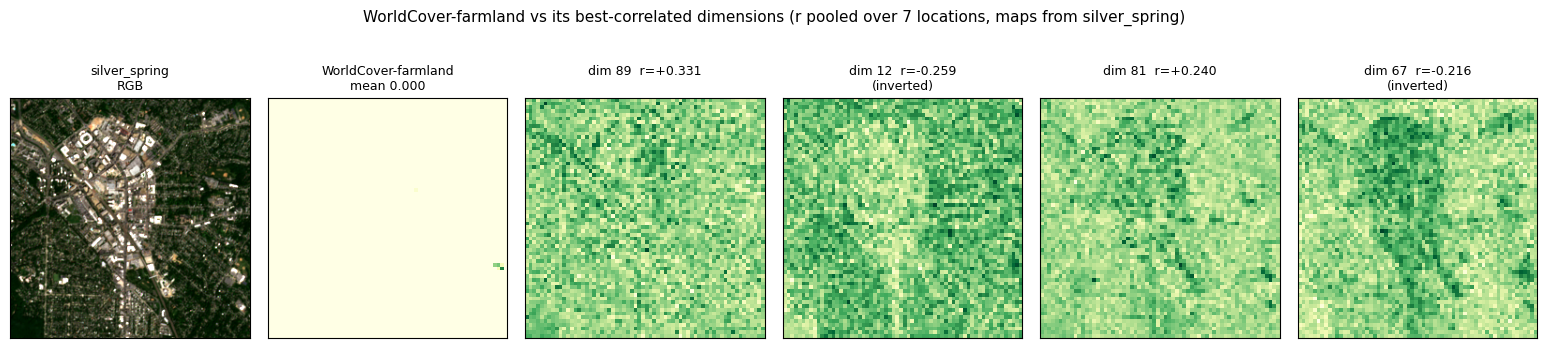

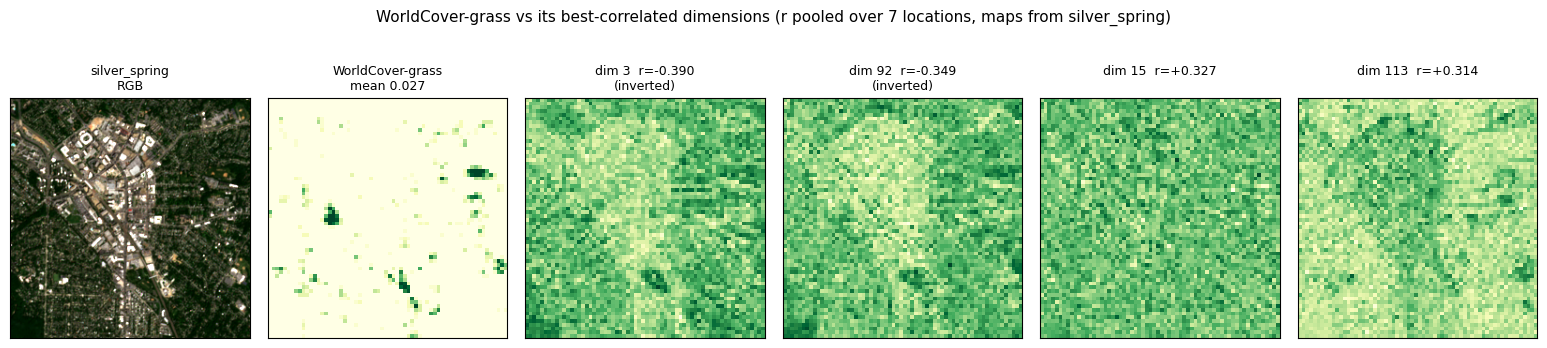

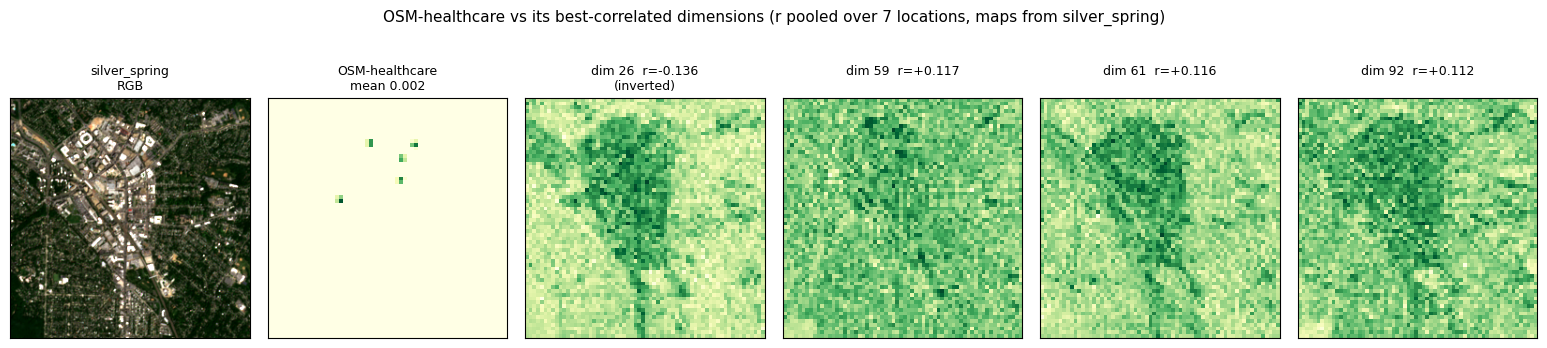

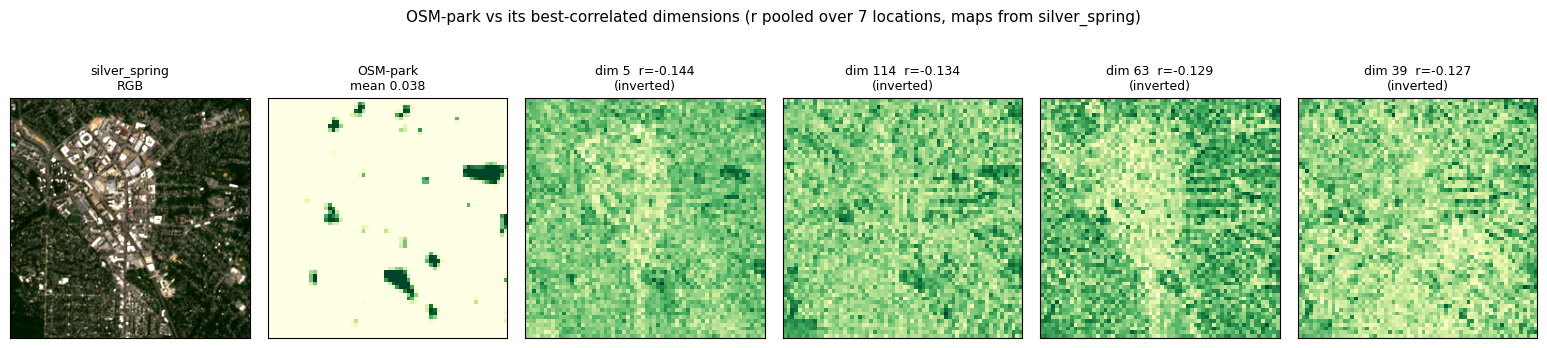

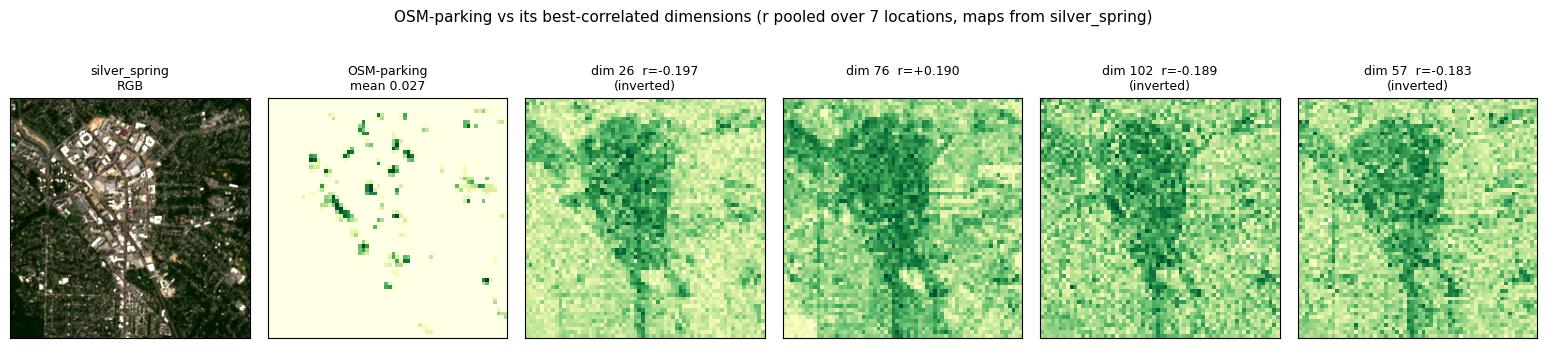

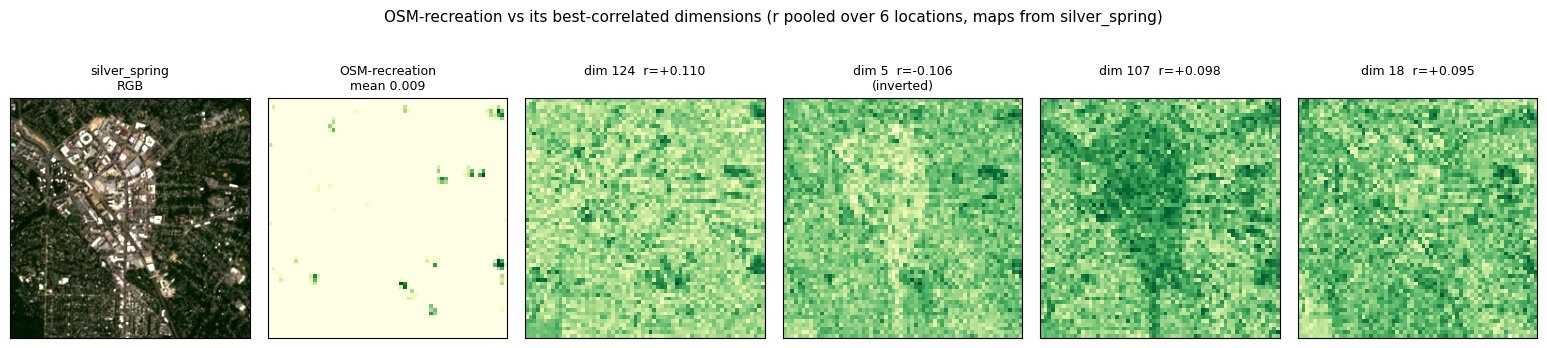

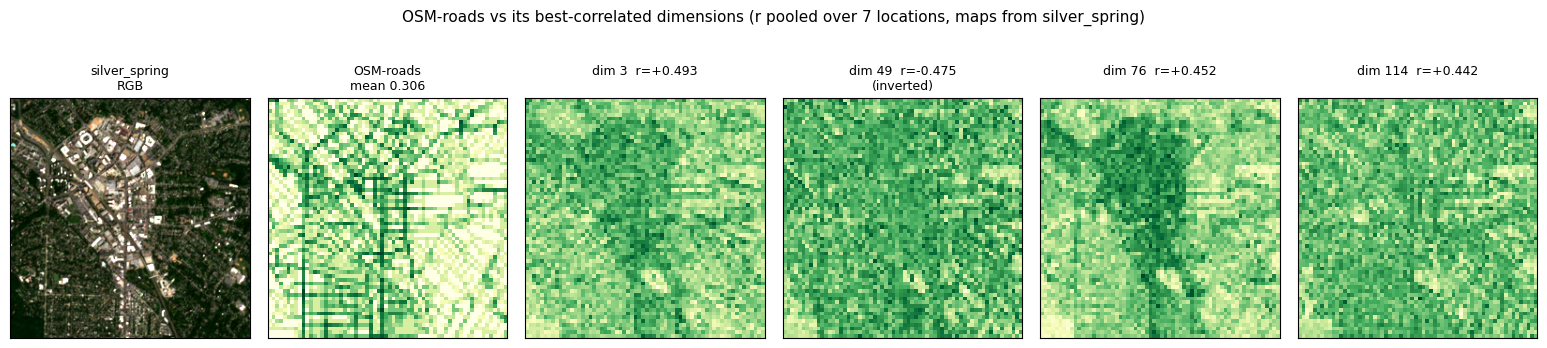

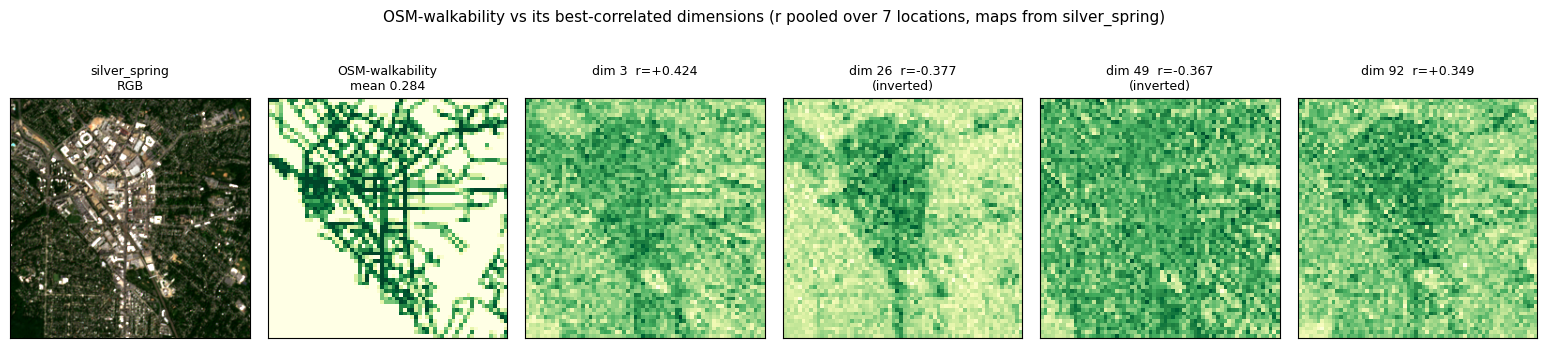

In [46]:
for label in sorted(set(corr["label"]) & set(labels)):
    try:
        compare_label_to_dims(LOCATION, label, 4, corr)
    except ValueError as exc:
        print(f"skipped {label}: {exc}")

### Same dimension across locations

Fix a dimension and a label, then look at every location. A dimension that
genuinely encodes a concept should track it everywhere, not just where it was
found.

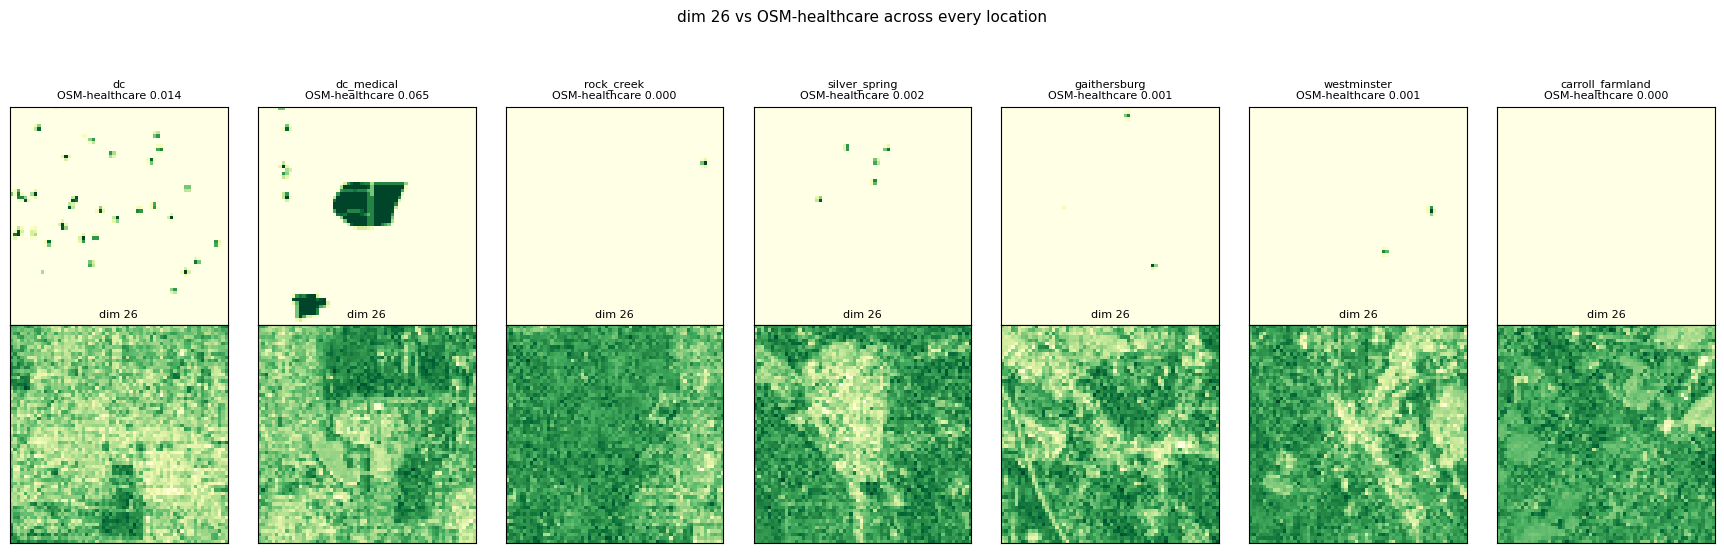

In [47]:
DIM = int(corr[corr["label"] == LABEL].iloc[0]["dim"])

sites = [
    n for n in loc.load_locations()
    if (ARTIFACTS / n / f"{n}.npz").exists() and LABEL in load_labels(n)
]
fig, axes = plt.subplots(2, len(sites), figsize=(2.5 * len(sites), 5.6), squeeze=False)
for j, site in enumerate(sites):
    site_labels = load_labels(site)
    axes[0][j].imshow(
        site_labels[LABEL], cmap="YlGn", vmin=0, vmax=1, interpolation="nearest"
    )
    axes[0][j].set_title(
        f"{site}\n{display_label(LABEL)} {float(site_labels[LABEL].mean()):.3f}",
        fontsize=8,
    )
    axes[1][j].imshow(
        load_embeddings(site)[:, :, DIM], cmap="YlGn", interpolation="nearest"
    )
    axes[1][j].set_title(f"dim {DIM}", fontsize=8)
    for i in (0, 1):
        axes[i][j].set_xticks([]); axes[i][j].set_yticks([])
fig.suptitle(
    f"dim {DIM} vs {display_label(LABEL)} across every location", fontsize=11
)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

---

## Reading these results honestly

- **No p-values anywhere.** Neighbouring patches share ground, so ~28,000
  patches carry far less independent information than the count suggests. With
  seven locations, everything here is exploratory.
- **`probe_r2_oof` is the headline**, not `pearson_r`. It is scored on
  locations the probe never saw, so it answers "would this transfer". Negative
  means it did not transfer at all, which is why negatives are shown rather than
  clipped.
- **Circularity.** WorldCover and the OSM `building`/`highway`/`parking` rasters
  were all OlmoEarth pretraining modalities, so a strong result partly reflects
  the model having learned its own training target. Fine for interpreting what a
  dimension means; weaker evidence about generalisation.
- **`WorldCover-built` is not `OSM-buildings`.** The first is every impervious
  surface — roofs, roads, parking, driveways — the second is roof outlines alone.
  On `dc_medical` they read 0.607 and 0.171.
- **`WorldCover-farmland` is row crops only.** Pasture and hay land in `grass`;
  `agriculture` combines both.
- **`OSM-walkability` is pedestrian infrastructure, not a walkability index.**
  Footways, paths, steps, pedestrian streets, cycleways. Real walkability
  combines intersection density, land-use mix and destination access; for that,
  at tract level, use EPA's National Walkability Index. This label is also
  confounded with how thoroughly an area has been mapped.
- **`OSM-healthcare` and `OSM-food_retail` are mostly points.** A pharmacy is one
  OSM node with no outline, expanded here to a 60 m disc so it occupies any
  patches at all. `hospitals` is separated out because campuses do have real
  outlines.
- **Coverage predicts success better than the label does.** Across the first run,
  everything above ~0.28 coverage transferred and everything at or below 0.03 did
  not. So a null for `healthcare` means "too rare in seven chips", not "the model
  cannot see it".